importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import math

Loading the dataset

In [2]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [3]:
weather_train_df.columns

Index(['site_id', 'timestamp', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed'],
      dtype='object')

Starting with weather dataset

In [4]:
weat_cop=weather_train_df.copy()

array([[<Axes: title={'center': 'site_id'}>,
        <Axes: title={'center': 'air_temperature'}>,
        <Axes: title={'center': 'cloud_coverage'}>],
       [<Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>],
       [<Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>, <Axes: >]], dtype=object)

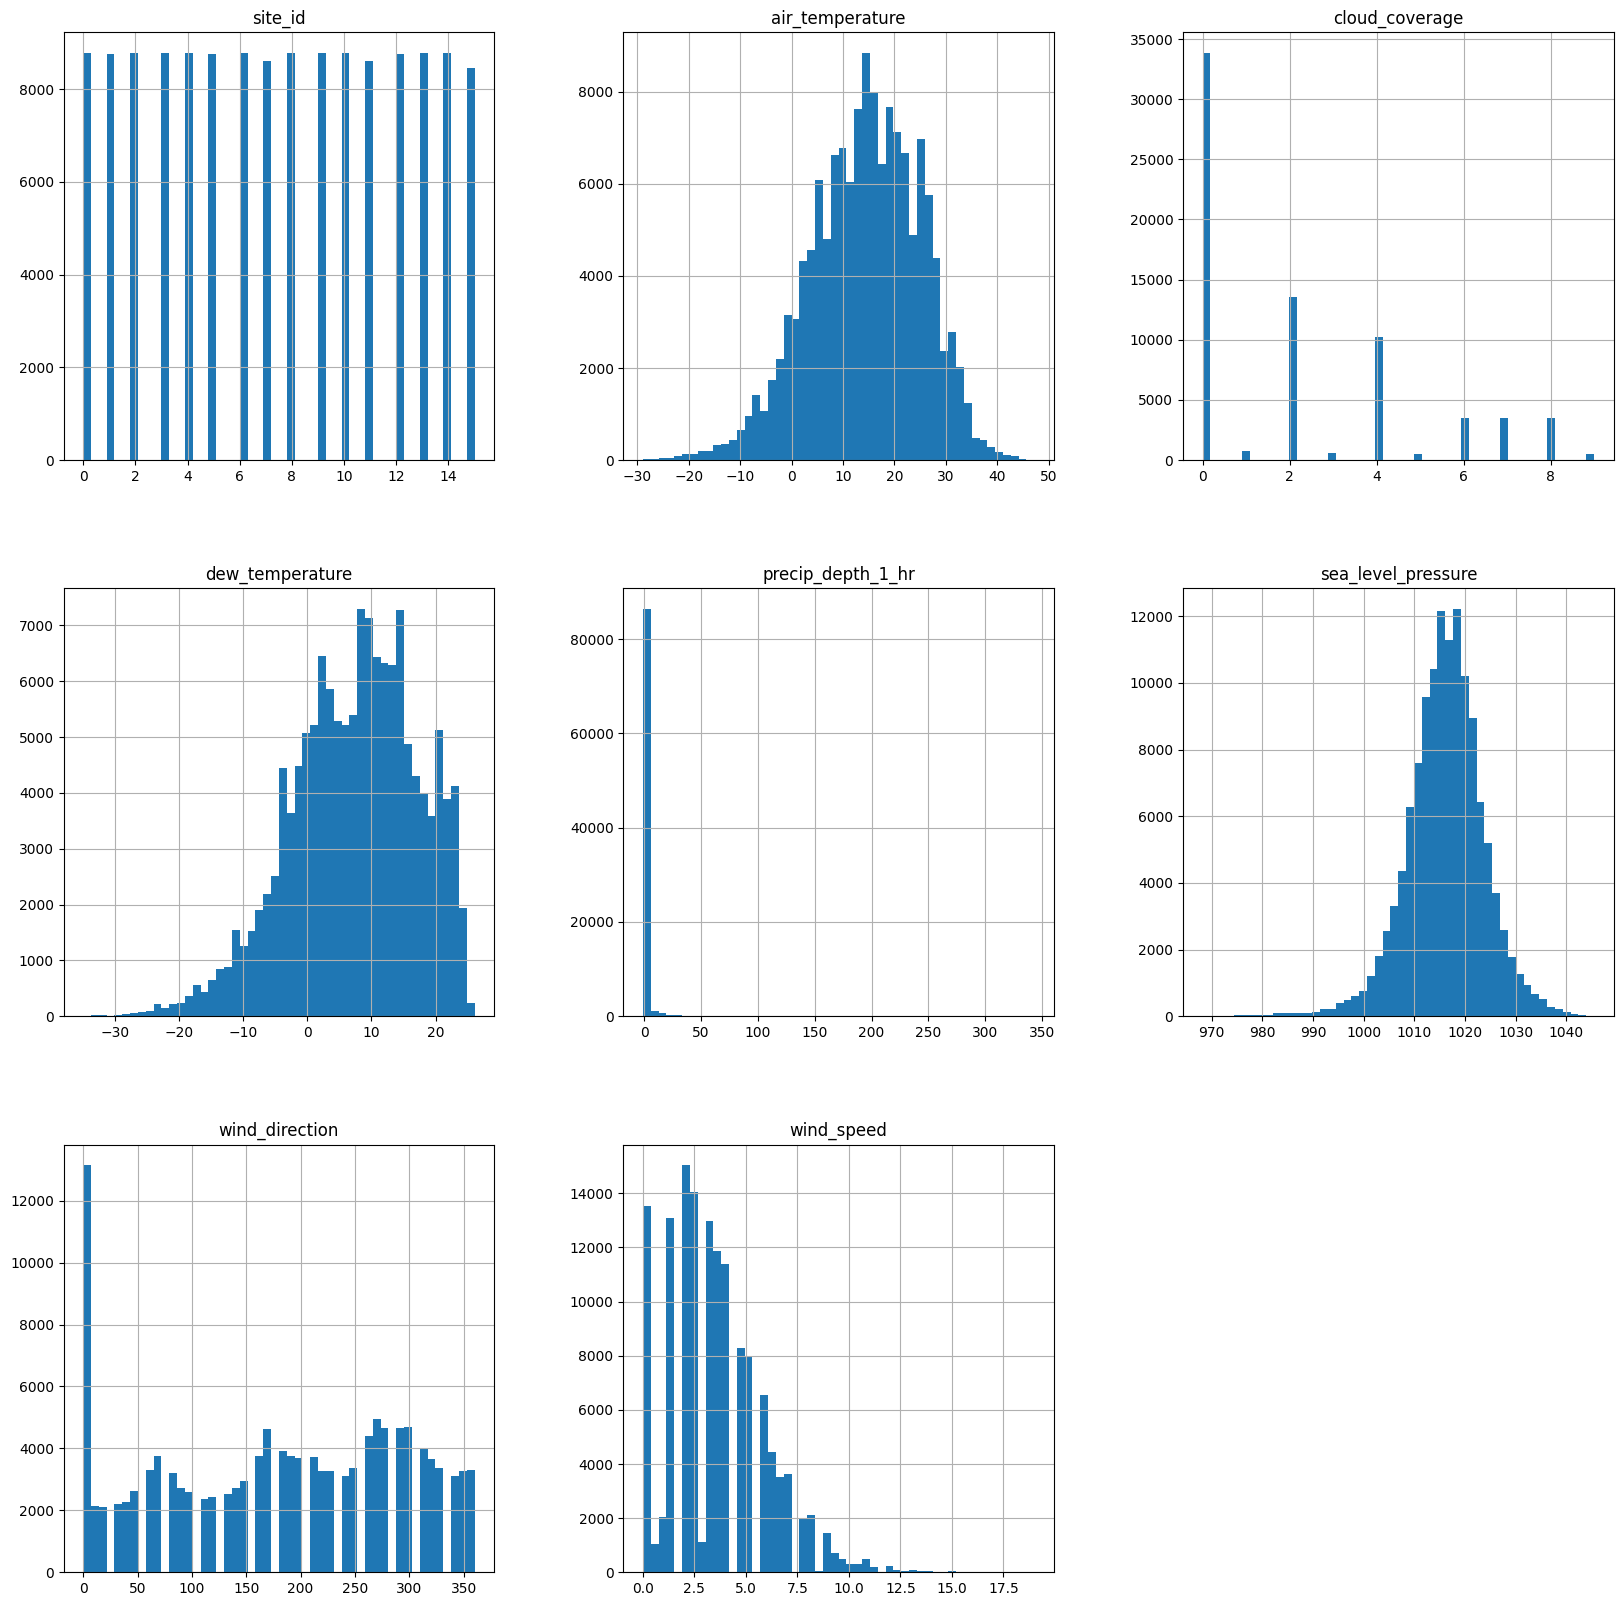

In [5]:
weat_cop.hist(bins=50,figsize=(20,20))

Adding feels like and relative humidity

In [6]:
def saturation_vapor_pressure(temperature):
    return 6.112 * math.exp((17.67 * temperature) / (temperature + 243.5))

# Function to calculate relative humidity
def relative_humidity(air_temp, dew_temp):
    E_air = saturation_vapor_pressure(air_temp)
    E_dew = saturation_vapor_pressure(dew_temp)
    RH = (E_dew / E_air) * 100
    return RH

# Apply the function to each row in the dataframe to calculate relative humidity
weat_cop['relative_humidity'] = weat_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)
# test_wet_cop['relative_humidity'] = test_wet_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)

In [7]:
# Simplified heat index (Rothfusz regression approximation)
weat_cop['heat_index'] = (
    0.5 * (weat_cop['air_temperature'] + 61.0 + 
    (weat_cop['air_temperature'] - 68.0) * 1.2 + 
    weat_cop['dew_temperature'] * 0.094
)
)

# Wind chill (for temps < 10°C and wind > 4.8 km/h)
mask = (weat_cop['air_temperature'] < 10) & (weat_cop['wind_speed'] > 1.34)  # 1.34 m/s ≈ 4.8 km/h
weat_cop['wind_chill'] = (
    13.12 + 0.6215 * weat_cop['air_temperature'] - 
    11.37 * (weat_cop['wind_speed'] ** 0.16) + 
    0.3965 * weat_cop['air_temperature'] * (weat_cop['wind_speed'] ** 0.16)
)
weat_cop['wind_chill'] = weat_cop['wind_chill'].where(mask, weat_cop['air_temperature'])

weat_cop['feels_like'] = np.where(
    weat_cop['air_temperature'] >= 27,  # Hot threshold
    weat_cop['heat_index'],
    np.where(
        weat_cop['air_temperature'] <= 10,  # Cold threshold
        weat_cop['wind_chill'],
        weat_cop['air_temperature']  # Default
    )
)

Convertinig timestamp to hour,day,month,day of year, weekend, season, and cyclic encoding for hour,day,month

In [8]:
import numpy as np
import pandas as pd

# Assuming weat_cop is your weather dataframe
weat_cop["timestamp"] = pd.to_datetime(weat_cop["timestamp"])

# Extract basic time features
weat_cop["hour"] = weat_cop["timestamp"].dt.hour
weat_cop["day_of_week"] = weat_cop["timestamp"].dt.weekday  # Monday=0, Sunday=6
weat_cop["month"] = weat_cop["timestamp"].dt.month
weat_cop["day_of_year"] = weat_cop["timestamp"].dt.dayofyear
weat_cop["is_weekend"] = (weat_cop["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour
weat_cop["hour_sin"] = np.sin(2 * np.pi * weat_cop["hour"] / 24)
weat_cop["hour_cos"] = np.cos(2 * np.pi * weat_cop["hour"] / 24)

# Cyclical encoding for day of the week
weat_cop["day_sin"] = np.sin(2 * np.pi * weat_cop["day_of_week"] / 7)
weat_cop["day_cos"] = np.cos(2 * np.pi * weat_cop["day_of_week"] / 7)

# Cyclical encoding for month
weat_cop["month_sin"] = np.sin(2 * np.pi * weat_cop["month"] / 12)
weat_cop["month_cos"] = np.cos(2 * np.pi * weat_cop["month"] / 12)

# Season encoding (0: Winter, 1: Spring, 2: Summer, 3: Fall)
weat_cop["season"] = weat_cop["month"].map(lambda m: 0 if m in [12, 1, 2] else
                                         1 if m in [3, 4, 5] else
                                         2 if m in [6, 7, 8] else 3)

# Drop original timestamp column if no longer needed
# weat_cop.drop(columns=["timestamp"], inplace=True)

# Display updated dataframe
weat_cop.head()


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,relative_humidity,...,month,day_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,73.780558,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,0.5,0.866025,0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5,81.848292,...,1,1,0,0.258819,0.965926,-0.433884,-0.900969,0.5,0.866025,0
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0,90.139994,...,1,1,0,0.500000,0.866025,-0.433884,-0.900969,0.5,0.866025,0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0,96.968347,...,1,1,0,0.707107,0.707107,-0.433884,-0.900969,0.5,0.866025,0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6,100.000000,...,1,1,0,0.866025,0.500000,-0.433884,-0.900969,0.5,0.866025,0


Capping feels like at -10 low and 35 high as after this the load will always be at max

In [9]:
T_min = -10  # Below this, heating load is maxed
T_max = 35   # Above this, cooling load is maxed

weat_cop['feels_like_capped'] = weat_cop['feels_like'].clip(T_min, T_max)
weat_cop['feels_like_capped']

0         25.000000
1         24.400000
2         22.800000
3         21.100000
4         20.000000
            ...    
139768     1.534909
139769     0.637652
139770     1.544926
139771     1.086355
139772    -0.970798
Name: feels_like_capped, Length: 139773, dtype: float64

linear interpolating precipitation data to fill the -1 values with a 6 hour limit interpolation or 0 otherwise

In [10]:

weat_cop['precip_depth_1_hr'] = (
    weat_cop['precip_depth_1_hr']
    .replace(-1.0, np.nan)
    .interpolate(method='linear', limit=6)  # 6-hour gap limit
    .fillna(0)  # Fill remaining gaps with 0
)

Adding bins for rain intensity based on precipitation data

In [11]:
bins = [-0.1, 0.1, 5.0, 15.0, float('inf')]  # -0.1 to catch near-zero values  
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']  

weat_cop['precip_1h_category'] = pd.cut(
    weat_cop['precip_depth_1_hr'],  
    bins=bins,  
    labels=labels  
)

In [12]:
weat_cop['is_light_rain'] = (weat_cop['precip_depth_1_hr'] > 0.1).astype(int)  

weat_cop['is_moderate_rain'] = ((weat_cop['precip_depth_1_hr'] > 5.0) & (weat_cop['precip_depth_1_hr'] < 15.0)).astype(int)

weat_cop['is_heavy_rain'] = (weat_cop['precip_depth_1_hr'] >= 15.0).astype(int)  

Winsorize sea level pressure to handle outliers

In [13]:
from scipy.stats.mstats import winsorize

weat_cop["sea_level_pressure"] = winsorize(weat_cop["sea_level_pressure"], limits=[0.01, 0.01])  # Capping at 0.5% on both ends

In [14]:
selected_features = [
    "site_id","relative_humidity", "feels_like_capped", "wind_speed", "precip_1h_category", "is_light_rain", "is_moderate_rain", "is_heavy_rain", 
    'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season','timestamp'
]

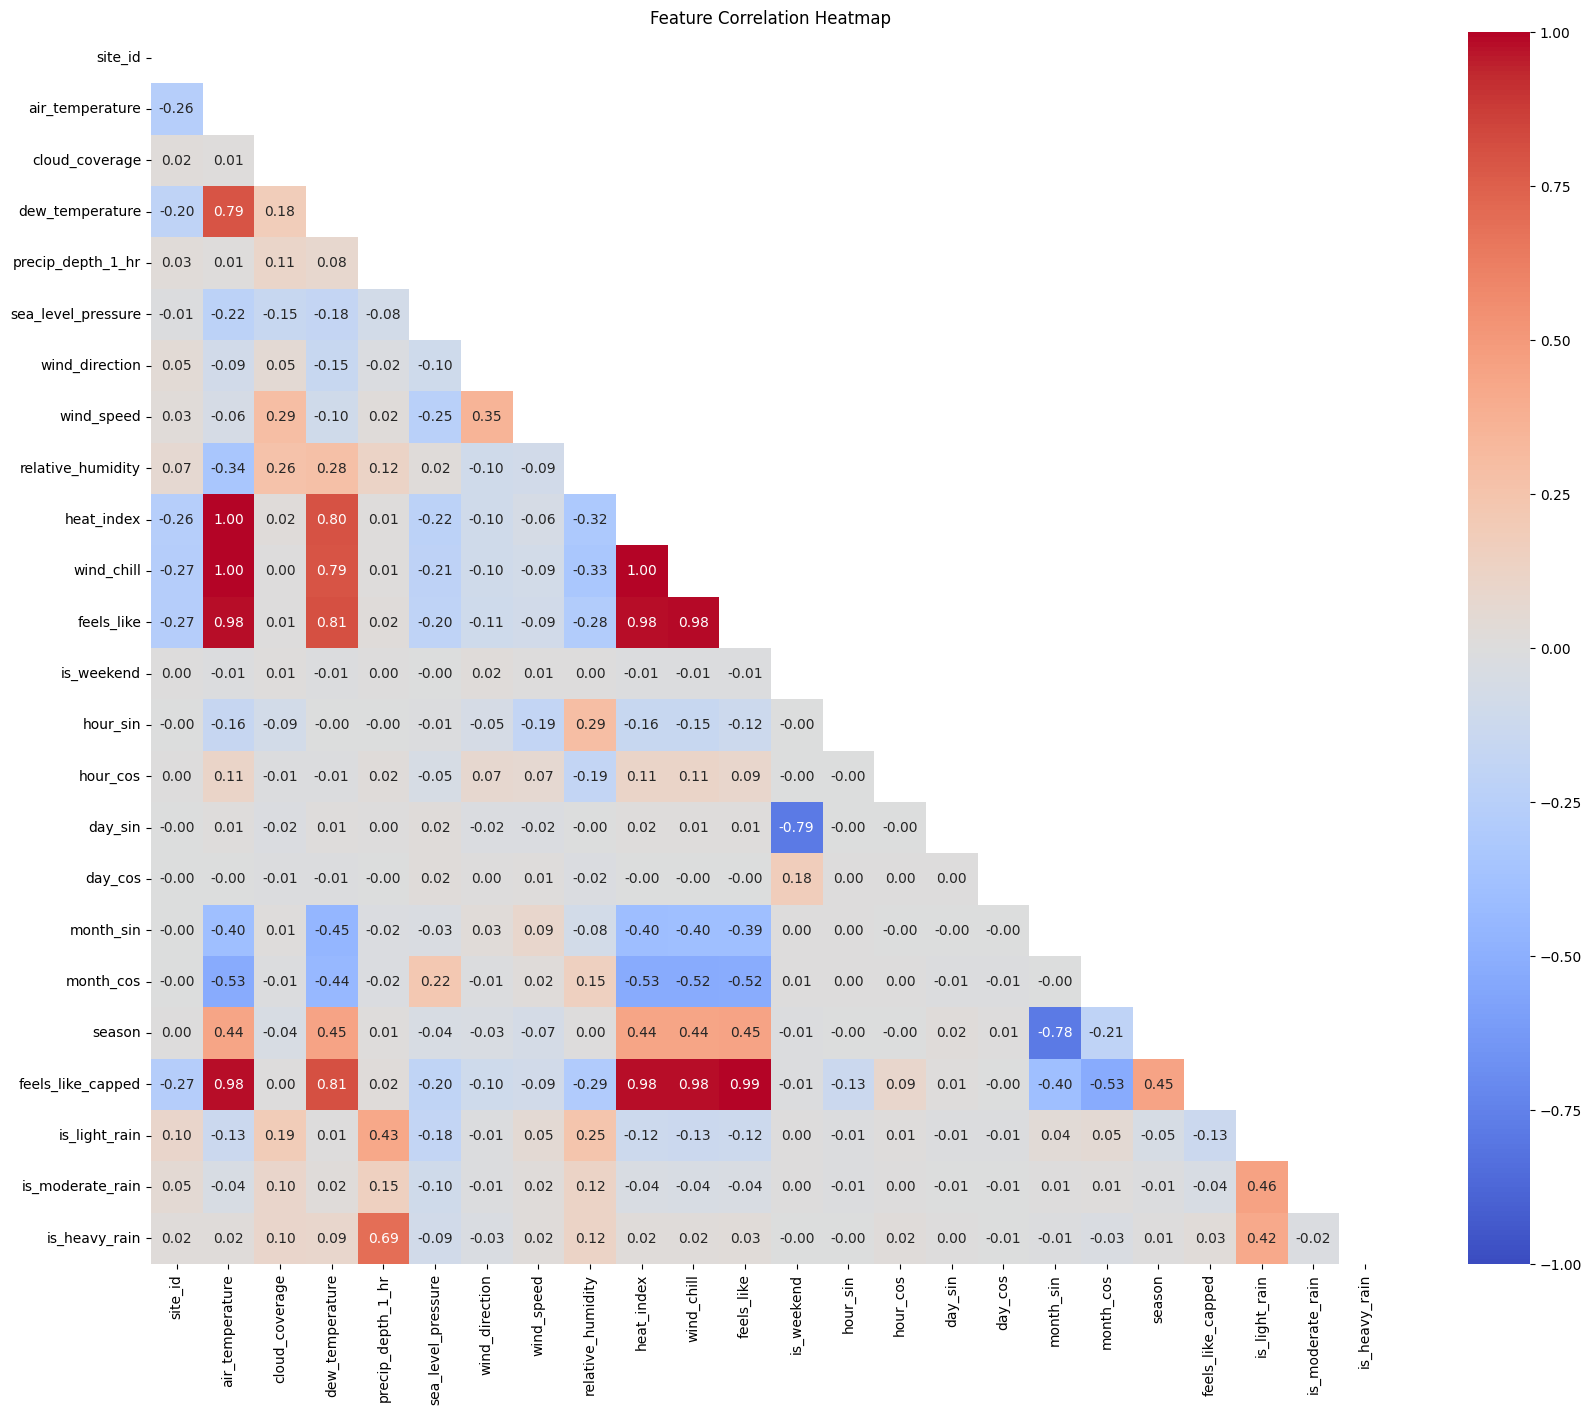

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = weat_cop.select_dtypes(include=['float64', 'int64']).columns
corr_df = weat_cop[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

checking feels like against months

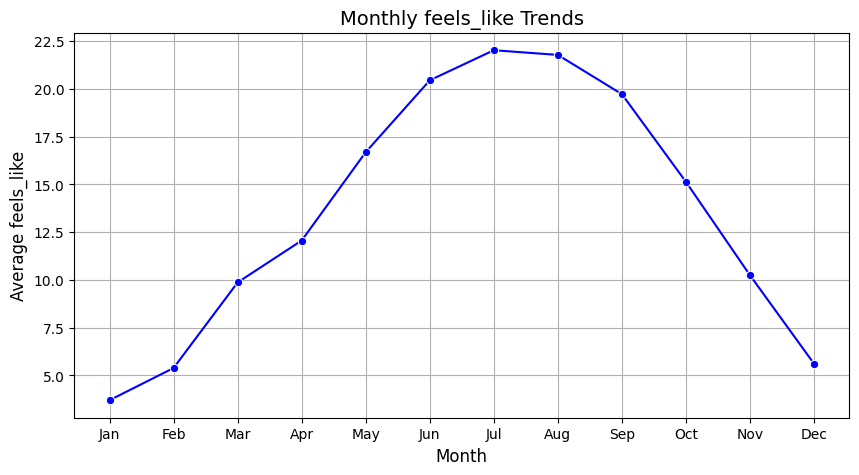

In [16]:
monthly_readings = weat_cop.groupby("month")["feels_like_capped"].mean()

# Plot
plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_readings.index, y=monthly_readings.values, marker="o", linestyle="-", color="b")

# Labels and title
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average feels_like", fontsize=12)
plt.title("Monthly feels_like Trends", fontsize=14)
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)

# Show plot
plt.show()

In [17]:
weat_cop.columns

Index(['site_id', 'timestamp', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'relative_humidity', 'heat_index',
       'wind_chill', 'feels_like', 'hour', 'day_of_week', 'month',
       'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'season', 'feels_like_capped',
       'precip_1h_category', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain'],
      dtype='object')

In [18]:
Final_weat=weat_cop[selected_features]

In [19]:
# Final_weat.isna().sum()

In [20]:
Final_weat[['feels_like_capped', 'relative_humidity', 'wind_speed']] = (
    Final_weat[['feels_like_capped', 'relative_humidity', 'wind_speed']].interpolate(method="linear")
)


C:\Users\zyzai\AppData\Local\Temp\ipykernel_22556\3843479888.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Final_weat[['feels_like_capped', 'relative_humidity', 'wind_speed']] = (


Handling the building data

In [21]:
buil_cop=building_df.copy()

In [22]:
buil_cop.isna().sum()

site_id           0
building_id       0
primary_use       0
square_feet       0
year_built      774
floor_count    1094
dtype: int64

dropping year built and floor count

In [23]:
buil_cop.drop(columns=['floor_count','year_built'],inplace=True)

Encoding primary type

In [24]:
label_encoder = LabelEncoder()

buil_cop['type_enc'] = label_encoder.fit_transform(buil_cop['primary_use'])



Converting sqaure feet to log values

In [25]:
buil_cop['square_feet_log'] = np.log1p(buil_cop['square_feet'])

dropping handled values

In [26]:
buil_cop.drop(columns=['primary_use','square_feet'],inplace=True)

In [27]:
# buil_cop.shape

Merging train and build data

In [28]:
train_merged = train_df.merge(buil_cop, on="building_id", how="left")

In [29]:
train_merged["timestamp"] = pd.to_datetime(train_merged["timestamp"])

merging the weather data with the train merged

In [30]:
main_merged = train_merged.merge(Final_weat, on=["site_id", "timestamp"], how="inner")

In [31]:
main_merged.shape

(20125605, 26)

In [32]:
main_merged.isna().sum()

building_id           0
meter                 0
timestamp             0
meter_reading         0
site_id               0
type_enc              0
square_feet_log       0
relative_humidity     0
feels_like_capped     0
wind_speed            0
precip_1h_category    0
is_light_rain         0
is_moderate_rain      0
is_heavy_rain         0
hour                  0
day_of_week           0
month                 0
day_of_year           0
is_weekend            0
hour_sin              0
hour_cos              0
day_sin               0
day_cos               0
month_sin             0
month_cos             0
season                0
dtype: int64

In [33]:
main_merged.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'type_enc', 'square_feet_log', 'relative_humidity', 'feels_like_capped',
       'wind_speed', 'precip_1h_category', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain', 'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season'],
      dtype='object')

In [34]:
main_merged["meter_reading"] = np.log1p(main_merged["meter_reading"])

In [ ]:
main_merged.loc[(main_merged["site_id"] == 0) & (main_merged["meter"] == 0), "meter_reading"] *= 0.293071

In [35]:
drop_0readings= list(main_merged[main_merged['meter_reading']==0.0].index)
main_merged.drop(drop_0readings, axis=0, inplace=True)

In [36]:
features=['building_id', 'meter', 'site_id',
       'type_enc', 'square_feet_log', 'relative_humidity', 'feels_like_capped',
       'wind_speed', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain', 'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season']
target = "meter_reading"

X = main_merged[features]
y = main_merged[target]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [37]:
def rmsle_lgbm(y_pred, data):

    y_true = np.array(data.get_label())
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False


In [40]:
# params = {
#     "objective": "regression",
#     "metric": "rmse",
#     "boosting_type": "gbdt",
#     "learning_rate": 0.05,
#     "num_leaves": 31,
#     "max_depth": -1,
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "n_estimators": 1000,
#     "verbose": -1
# }

# # Convert to LightGBM dataset
# train_data = lgb.Dataset(X_train, label=y_train)
# val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# # Train the model
# # model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
# model = lgb.train(
#     params,
#     train_data,
#     valid_sets=[val_data],
#     callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
# )


params = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 51,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 1300,
    "verbose": -1
}

# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train the model
# model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)],
    feval=rmsle_lgbm
)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.77632	valid_0's rmsle: 0.220997
[200]	valid_0's l2: 0.607555	valid_0's rmsle: 0.197639
[300]	valid_0's l2: 0.528562	valid_0's rmsle: 0.184489
[400]	valid_0's l2: 0.477481	valid_0's rmsle: 0.176263
[500]	valid_0's l2: 0.432134	valid_0's rmsle: 0.168328
[600]	valid_0's l2: 0.39915	valid_0's rmsle: 0.162184
[700]	valid_0's l2: 0.372761	valid_0's rmsle: 0.157352
[800]	valid_0's l2: 0.349419	valid_0's rmsle: 0.152584
[900]	valid_0's l2: 0.333236	valid_0's rmsle: 0.149255
[1000]	valid_0's l2: 0.317726	valid_0's rmsle: 0.146304
[1100]	valid_0's l2: 0.305216	valid_0's rmsle: 0.143584
[1200]	valid_0's l2: 0.291781	valid_0's rmsle: 0.140794
[1300]	valid_0's l2: 0.282029	valid_0's rmsle: 0.138447
Did not meet early stopping. Best iteration is:
[1300]	valid_0's l2: 0.282029	valid_0's rmsle: 0.138447


In [41]:
from sklearn.metrics import r2_score
y_train_pred = model.predict(X_train)

# Calculate R² Score
r2 = r2_score(y_train, y_train_pred)
print("Training R² Score:", r2)
y_test_pred = model.predict(X_val)

# Calculate R² Score
r2_test = r2_score(y_val, y_test_pred)
print("Test R² Score:", r2_test)

Training R² Score: 0.9107064631014119
Test R² Score: 0.910170487224822


In [40]:
main_merged.drop(columns='precip_1h_category',inplace=True)

In [41]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

# Assume main_merged is your DataFrame and already loaded

# Normalize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape the data to simulate sequential (time-series) format (optional)
# If this is not time-series data and you want to work with LSTMs for sequence prediction
# you can treat it as sequences by adding a time axis (e.g., using sliding windows).

# Example: Reshaping into sequences (if needed)
sequence_length = 10  # You can change this based on your use case
generator = TimeseriesGenerator(X_scaled, y, length=sequence_length, batch_size=32)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
# Reshape X_train and X_val to be 3D (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_val = X_val.reshape((X_val.shape[0], 1, X_val.shape[1]))

# Check the shape of the data after reshaping
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Initialize the model
model = Sequential()

# LSTM layer: input_shape should match (timesteps, features)
model.add(LSTM(units=64, activation='tanh', input_shape=(X_train.shape[1], X_train.shape[2])))

# Optionally add a Dropout layer to prevent overfitting
model.add(Dropout(0.2))

# Fully connected output layer
model.add(Dense(units=1))  # For regression, no activation function here

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Summary of the model to check the architecture
model.summary()


X_train shape: (14606174, 1, 23)
X_val shape: (3651544, 1, 23)


c:\Users\c24101927\ML_Project\ML_project\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,593 (88.25 KB)

 Trainable params: 22,593 (88.25 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_data=(X_val, y_val))


Epoch 1/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 577s 1ms/step - loss: 1.3346 - val_loss: 0.9352
Epoch 2/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 567s 1ms/step - loss: 1.0046 - val_loss: 0.8666
Epoch 3/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 558s 1ms/step - loss: 0.9528 - val_loss: 0.8362
Epoch 4/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 555s 1ms/step - loss: 0.9258 - val_loss: 0.8134
Epoch 5/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 553s 1ms/step - loss: 0.9075 - val_loss: 0.7953
Epoch 6/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 550s 1ms/step - loss: 0.8952 - val_loss: 0.7790
Epoch 7/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 547s 1ms/step - loss: 0.8851 - val_loss: 0.7701
Epoch 8/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 548s 1ms/step - loss: 0.8787 - val_loss: 0.7621
Epoch 9/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 556s 1ms/step - loss: 0.8708 - val_loss: 0.7605
Epoch 10/10
456443/456443 ━━━━━━━━━━━━━━━━━━━━ 552s 1ms/step - loss: 0.8676 - val_loss: 0.7550


In [46]:
# Evaluate the model on validation data
loss = model.evaluate(X_val, y_val)
print(f"Validation Loss: {loss}")


114111/114111 ━━━━━━━━━━━━━━━━━━━━ 86s 750us/step - loss: 0.7549
Validation Loss: 0.7549654245376587


In [47]:
# Example: Predictions on validation set
y_pred = model.predict(X_val)

# Optionally, inverse scaling if you need to revert the normalized values back
# y_pred = scaler.inverse_transform(y_pred)  # if needed (if scaling was done)

# Check the first 5 predictions
print("Predictions:", y_pred[:5])


114111/114111 ━━━━━━━━━━━━━━━━━━━━ 66s 581us/step
Predictions: [[2.8484206]
 [4.833436 ]
 [3.9639266]
 [3.2974303]
 [4.646899 ]]


In [48]:
from sklearn.metrics import r2_score
y_train_pred = model.predict(X_train)

# Calculate R² Score
r2 = r2_score(y_train, y_train_pred)
print("Training R² Score:", r2)
y_test_pred = model.predict(X_val)

# Calculate R² Score
r2_test = r2_score(y_val, y_test_pred)
print("Test R² Score:", r2_test)

456443/456443 ━━━━━━━━━━━━━━━━━━━━ 274s 601us/step
Training R² Score: 0.7598997626806749
114111/114111 ━━━━━━━━━━━━━━━━━━━━ 77s 679us/step
Test R² Score: 0.7595350351314191


In [51]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# Assuming you already have the train and validation data
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(
    objective='reg:squarederror',  # Typical regression task
    colsample_bytree=0.3,
    learning_rate=0.2,
    max_depth=6,
    alpha=10,
    n_estimators=300
)

# Fit the model
xg_reg.fit(X_train, y_train)

# Predict the values
y_pred = xg_reg.predict(X_val)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'XGBoost RMSE: {rmse}')


XGBoost RMSE: 0.7564061512910571


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the model
xg_reg = xgb.XGBRegressor(objective='reg:squarederror')

# Define the hyperparameter grid
param_grid = {
    'max_depth': [6,7],
    'learning_rate': [0.2,0.3],
    'n_estimators': [300,400]
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=xg_reg, param_grid=param_grid, cv=3, verbose=1)

# Fit GridSearchCV
grid_search.fit(X_train, y_train)

# Best hyperparameters
print(f"Best parameters: {grid_search.best_params_}")


    # 'max_depth': [3, 4, 5, 6],
    # 'learning_rate': [0.01, 0.1, 0.2],
    # 'n_estimators': [100, 200, 300]

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best parameters: {'learning_rate': 0.2, 'max_depth': 6, 'n_estimators': 300}


In [ ]:
import xgboost as xgb
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize the XGBoost model
xg_reg = xgb.XGBRegressor(
    objective='reg:squarederror',  # Typical regression task
    colsample_bytree=0.3,
    learning_rate=0.1,
    max_depth=5,
    alpha=10,
    n_estimators=100
)

# Perform cross-validation
cv_scores = cross_val_score(xg_reg, X, y, cv=5, scoring='neg_root_mean_squared_error')

# Convert the negative RMSE to positive values
cv_rmse = -cv_scores

print(f'Cross-validated RMSE for XGBoost: {cv_rmse}')
print(f'Mean RMSE: {cv_rmse.mean()}')
print(f'Standard Deviation of RMSE: {cv_rmse.std()}')


In [ ]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# ➤ STEP 1: Load and Prepare Data
features = ["site_id", "square_feet_log", "relative_humidity", "feels_like_capped", 
            "wind_speed", "precip_1h_category", "is_light_rain", "is_moderate_rain",
            "is_heavy_rain", "hour_sin", "hour_cos", "day_sin", "day_cos", "month_sin", "month_cos"]

X = main_merged[features]
y = main_merged["meter_reading"]

# ➤ STEP 2: Train LightGBM
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.03,
    "num_leaves": 60,
    "max_depth": -1,
    "boosting_type": "gbdt",
    "verbose": -1,
}

lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

model_lgb = lgb.train(lgb_params, lgb_train, valid_sets=[lgb_train, lgb_val], 
                      num_boost_round=1200, early_stopping_rounds=50, verbose_eval=100)

# ➤ STEP 3: Compute Residuals for LSTM
y_pred_lgb = model_lgb.predict(X_val)
residuals = y_val - y_pred_lgb  # What LightGBM couldn’t capture

# ➤ STEP 4: Normalize Residuals for LSTM
scaler = MinMaxScaler()
residuals_scaled = scaler.fit_transform(residuals.values.reshape(-1, 1))

# ➤ STEP 5: Prepare Data for LSTM (Sliding Window)
time_steps = 48  # Use last 48 hours as context
X_lstm, y_lstm = [], []

for i in range(len(residuals_scaled) - time_steps):
    X_lstm.append(residuals_scaled[i: i + time_steps])
    y_lstm.append(residuals_scaled[i + time_steps])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# ➤ STEP 6: Train LSTM on Residuals
model_lstm = Sequential([
    LSTM(64, activation="relu", return_sequences=True, input_shape=(time_steps, 1)),
    Dropout(0.2),
    LSTM(32, activation="relu"),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.fit(X_lstm, y_lstm, epochs=10, batch_size=256, validation_split=0.2)

# ➤ STEP 7: Predict Residual Corrections using LSTM
y_pred_residuals = model_lstm.predict(X_lstm)
y_pred_residuals = scaler.inverse_transform(y_pred_residuals)  # Convert back to original scale

# ➤ STEP 8: Combine LightGBM Predictions with LSTM Corrections
y_final_pred = y_pred_lgb[:len(y_pred_residuals)] + y_pred_residuals.flatten()

# ➤ STEP 9: Evaluate Final Hybrid Model
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_val[:len(y_final_pred)], y_final_pred))
print(f"Hybrid Model RMSE: {rmse:.4f}")
